# Fase 3 - Dead reckoning de IMU (ver la deriva)

Entradas:  `results/MH_01_easy/fase1_sync.npz`, `results/MH_01_easy/fase2_calib.npz`
           y los CSV crudos de `mav0/imu0/` y `mav0/state_groundtruth_estimate0/`
Salidas:   `results/MH_01_easy/fase3_dr.npz`

**Objetivo:** integrar SOLO la IMU, medir la deriva, y con ello fijar de una vez
por todas los convenios de ejes, gravedad y bias.

**Criterio de éxito:** con estado inicial y bias tomados del GT, el error de
posición a los **5 s** debe ser **< 0.5 m**. Si es de metros, tienes un bug, no
"deriva normal".

Esta fase es el filtro de calidad más eficaz de todo el pipeline: casi todos los
errores de convenio se manifiestan aquí, y son *imposibles* de localizar más
tarde. En la Fase 5 solo verías "el filtro no converge" sin saber por qué.

**Por qué volvemos a los CSV crudos.** La Fase 1 guardó el GT muestreado en los
instantes de CÁMARA (20 Hz) y solo con posición y orientación. Aquí hace falta la
IMU a 200 Hz y las columnas `v_RS_R` (velocidad) y `b_w_RS_S` / `b_a_RS_S` (bias)
del ground truth, que solo están en el CSV.

**Aviso de frames.** La extrínseca `T_imu_cam` de la Fase 2 **no se usa** en esta
fase. El GT de EuRoC son poses del cuerpo `B`, y para `imu0` la extrínseca `T_BS`
es la identidad: `B = IMU`. Cámara e IMU no vuelven a mezclarse hasta la Fase 4.
Si te ves aplicando `T_imu_cam` aquí, párate.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.spatial.transform import Rotation, Slerp

In [2]:
def encontrar_raiz(marcador="data"):
    actual = Path.cwd().resolve()
    for candidato in [actual, *actual.parents]:
        if (candidato / marcador).is_dir():
            return candidato
    raise FileNotFoundError(f"No encuentro '{marcador}/' hacia arriba desde {actual}")

In [3]:
RAIZ = encontrar_raiz()
ENTRADA_F1 = RAIZ / "results" / "MH_01_easy" / "fase1_sync.npz"
ENTRADA_F2 = RAIZ / "results" / "MH_01_easy" / "fase2_calib.npz"
SALIDA = RAIZ / "results" / "MH_01_easy" / "fase3_dr.npz"

np.set_printoptions(precision=8, suppress=True)

In [7]:
d1 = np.load(ENTRADA_F1, allow_pickle=True)
d2 = np.load(ENTRADA_F2, allow_pickle=True)

print("claves de fase1_sync.npz :", sorted(d1.files))
print("claves de fase2_calib.npz:", sorted(d2.files))

claves de fase1_sync.npz : ['K', 'T0_ns', 'T_imu_cam', 'accel', 'accel_medio_est', 'bias_giro_est', 'dist', 'g_body', 'gt_ba', 'gt_bw', 'gt_p', 'gt_p_cam', 'gt_q_cam_wxyz', 'gt_q_wxyz', 'gt_v', 'gt_v_cam', 'gyro', 'i0_estatico', 'i1_estatico', 'imu_fin', 'imu_ini', 'mask_gt', 'pitch0', 'residuo_gravedad', 'roll0', 'ruido_accelerometer_noise_density', 'ruido_accelerometer_random_walk', 'ruido_gyroscope_noise_density', 'ruido_gyroscope_random_walk', 'rutas_img', 'sigma_bias_giro', 't_arranque', 't_cam', 't_cam_gt', 't_despegue', 't_estatico', 't_gt', 't_imu', 't_motores']
claves de fase2_calib.npz: ['K', 'K_new', 'T_cam_imu', 'T_imu_cam', 'T_rel_gt', 'T_world_cam', 'ang_rel', 'desp_rel', 'dist', 'mapa_x', 'mapa_y', 'p_cam_world', 'roi', 't_cam_gt']


In [9]:
def sacar(npzs, *nombres, defecto=None):
    """Primera de 'nombres' que exista en ualquiera de los npz, o 'defectos'."""
    for npz in npzs:
        for nombre in nombres:
            if nombre in npz.files:
                return npz[nombre]
    if defecto is None:
        raise KeyError(f"ninguna de {nombres} está en los npz")
    print(f"  aviso: '{nombres[0]}' no está guardado, uso el valor por defecto {defecto}")
    return np.asarray(defecto)

In [10]:
rutas_img = sacar([d1], "rutas_img")
t_cam_gt = sacar([d1, d2], "t_cam_gt")

# Estos dos salieron de la Fase 1. 
T_ESTATICO = np.asarray(sacar([d1], "tramo_estatico", "t_estatico", defecto=[21.82, 30.98]), float)
T_ARRANQUE = float(sacar([d1], "t_arranque", defecto=45.82))

print(f"\ntramo estático = [{T_ESTATICO[0]:.2f}, {T_ESTATICO[1]:.2f}] s")
print(f"t_arranque     = {T_ARRANQUE:.2f} s")


tramo estático = [21.82, 30.98] s
t_arranque     = 45.82 s


## 3.0 - Datos crudos y base de tiempos

Dos cosas que conviene cerrar antes de integrar nada:

1. **Los timestamps de EuRoC son enteros de 64 bits en nanosegundos.** Leerlos
   como `float64` los cuantiza: 1.4e18 ns no cabe en una mantisa de 53 bits y la
   resolución efectiva pasa a ~256 ns. No es catastrófico (`dt` ≈ 5e6 ns), pero
   se arregla gratis restando el offset **en entero** y convirtiendo después. Es
   la última fila de la tabla de trampas de 3.7.

2. **La base de tiempos tiene que ser la misma que la de la Fase 1**, o
   `t_arranque` y el tramo estático apuntarán a otro sitio. Los nombres de
   fichero de `cam0` *son* el timestamp en ns, así que el offset que usaste en la
   Fase 1 se puede recuperar comparando con `t_cam_gt[0]` en vez de suponerlo.

In [15]:
# La ruta a mav0 se deduce de las imágenes de la Fase 1: .../mav0/cam0/data/<ts>.png
MAV0 = Path(str(rutas_img[0])).parents[2]
CSV_IMU = MAV0 / "imu0" / "data.csv"
CSV_GT = MAV0 / "state_groundtruth_estimate0" / "data.csv"

assert CSV_IMU.is_file(), f"no encuentro {CSV_IMU}"
assert CSV_GT.is_file(), f"no encuentro {CSV_GT}"
print(f"mav0 = {MAV0}")

mav0 = ..\data\MH_01_easy\mav0


In [16]:
def leer_csv_euroc(ruta, n_columnas):
    """
    CSV de EuRoC -> (timestamps en ns como int64, resto de columnas como float64).

    Dos pasadas a propósito: la primera columna se lee como ENTERO para no perder
    resolución temporal, el resto como flotante.
    """
    ts_ns = np.loadtxt(ruta, delimiter=",", skiprows=1, usecols=0, dtype=np.int64)
    datos = np.loadtxt(ruta, delimiter=",", skiprows=1, usecols=range(1, n_columnas), dtype=np.float64)
    return ts_ns, datos

In [18]:
ts_imu_ns, imu_datos = leer_csv_euroc(CSV_IMU, 7)
w_medida = imu_datos[:, 0:3]      # rad/s, frame body
a_medida = imu_datos[:, 3:6]      # m/s^2, frame body, FUERZA ESPECÍFICA

# state_groundtruth_estimate0: timestamp, p(3), q_wxyz(4), v(3), b_w(3), b_a(3)
ts_gt_ns, gt_datos = leer_csv_euroc(CSV_GT, 17)
gt_p = gt_datos[:, 0:3]
gt_q_wxyzgt_p = gt_datos[:, 0:3]
gt_q_wxyz = gt_datos[:, 3:7]
gt_v = gt_datos[:, 7:10]
gt_bg = gt_datos[:, 10:13]
gt_ba = gt_datos[:, 13:16]

print(f"IMU: {len(ts_imu_ns)} muestras")
print(f"GT : {len(ts_gt_ns)} muestras")

IMU: 36820 muestras
GT : 36382 muestras


In [19]:
# Base de tiempos: recupero el offset de la Fase 1 desde el nombre del primer PNG.
t_cam0_ns = int(Path(str(rutas_img[0])).stem)
OFFSET_NS = t_cam0_ns - int(round(float(t_cam_gt[0]) * 1e9))

t_imu = (ts_imu_ns - OFFSET_NS) / 1e9
t_gt = (ts_gt_ns - OFFSET_NS) / 1e9

print(f"offset de la Fase 1 = {OFFSET_NS} ns")
print(f"t_imu: [{t_imu[0]:8.3f}, {t_imu[-1]:8.3f}] s")
print(f"t_gt : [{t_gt[0]:8.3f}, {t_gt[-1]:8.3f}] s")
print(f"t_cam: [{t_cam_gt[0]:8.3f}, {t_cam_gt[-1]:8.3f}] s   <- de la Fase 1, debe solapar")

assert abs(t_imu[0] - float(t_cam_gt[0])) < 5.0, "las bases de tiempo no cuadran, revisa OFFSET_NS"

offset de la Fase 1 = 1403636578663555584 ns
t_imu: [   1.095,  185.190] s
t_gt : [   2.175,  184.080] s
t_cam: [   1.100,  182.950] s   <- de la Fase 1, debe solapar


In [20]:
# Estadística de dt: la IMU es de 200 Hz nominales, pero los dt NO son constantes.
dt_imu = np.diff(t_imu)
print(f"dt de la IMU:  media = {dt_imu.mean()*1e3:.4f} ms   std = {dt_imu.std()*1e6:.1f} us")
print(f"               min   = {dt_imu.min()*1e3:.4f} ms   max = {dt_imu.max()*1e3:.4f} ms")
print(f"frecuencia media = {1/dt_imu.mean():.2f} Hz")
assert dt_imu.min() > 0, "hay timestamps repetidos o desordenados en la IMU"

# Lo que habría costado leer el timestamp como float64 directamente:
dt_naive = np.diff(ts_imu_ns.astype(np.float64) / 1e9)
print(f"\ncuantización si el ts se lee como float64: max |Δdt| = "
      f"{np.abs(dt_naive - dt_imu).max()*1e9:.0f} ns")

dt de la IMU:  media = 5.0000 ms   std = 0.1 us
               min   = 4.9999 ms   max = 5.0002 ms
frecuencia media = 200.00 Hz

cuantización si el ts se lee como float64: max |Δdt| = 178 ns


## 3.1 - Las ecuaciones

Estado nominal: `x = (p_w, v_w, R_ws, b_g, b_a)`, donde `R_ws` lleva vectores del
frame body (`s`, el IMU) al mundo (`w`).

Medidas: `w_m` (rad/s, body), `a_m` (m/s², body, **fuerza específica**).

```
w = w_m - b_g - n_g
a = a_m - b_a - n_a

Ṙ_ws = R_ws · [w]×
v̇_w  = R_ws · a + g_w                 con g_w = (0, 0, -9.81)
ṗ_w  = v_w
ḃ_g  = n_bg          (random walk)
ḃ_a  = n_ba
```

**Por qué el acelerómetro no mide aceleración.** En caída libre marca cero; en
reposo marca `+g` en la dirección "arriba" del body. Lo que mide es la fuerza
específica `f = R_ws^T (a_w - g_w)`. Despejar `a_w = R_ws·f + g_w` es *la*
ecuación de la Fase 3, y el signo de `g_w` es donde se equivoca todo el mundo.

### Discretización

**Euler hacia adelante** (sencillo, error O(dt)):

```
R_{k+1} = R_k · Exp(w_k · dt)
a_w     = R_k · a_k + g_w
p_{k+1} = p_k + v_k·dt + 0.5·a_w·dt²
v_{k+1} = v_k + a_w·dt
```

**Punto medio / midpoint** (error O(dt²), el que hay que usar):

```
w̄       = 0.5 (w_k + w_{k+1})
R_{k+1} = R_k · Exp(w̄ · dt)
ā_w     = 0.5 (R_k·a_k + R_{k+1}·a_{k+1}) + g_w
p_{k+1} = p_k + v_k·dt + 0.5·ā_w·dt²
v_{k+1} = v_k + ā_w·dt
```

A 200 Hz la diferencia entre ambos en 5 s es de centímetros, pero se acumula. Y
midpoint es lo que usan VINS-Mono y la preintegración de GTSAM, así que es lo que
interesa tener interiorizado.

Ojo al orden `R · Exp(δ)`: la velocidad angular está medida **en el frame body**,
así que el incremento se compone **por la derecha**. `Exp(δ) · R` sería un
incremento expresado en el mundo, que no es lo que da el giróscopo. Este es
exactamente el mismo criterio que gobierna dónde va el "boxplus" en la
optimización sobre la variedad de la Fase 6.

In [21]:
def sombrero(v):
    """Matriz antisimétrica [v]x, tal que [v]x @ u = v × u."""
    v = np.asarray(v, dtype=np.float64)
    return np.array([[0.0, -v[2], v[1]],
                     [v[2], 0.0, -v[0]],
                     [-v[1], v[0], 0.0]])

In [22]:
def Exp(phi):
    """
    Exponencial de SO(3) (Rodrigues): vector de rotación (3,) -> matriz 3x3.

        Exp(phi) = I + (sin θ/θ)·[phi]x + ((1-cos θ)/θ²)·[phi]x²    con θ = |phi|

    Para θ pequeño esas divisiones pierden precisión, así que se usa el
    desarrollo I + [phi]x + [phi]x²/2. Con dt = 5 ms y 1 rad/s tenemos θ ~ 5e-3,
    lejos del umbral; pero θ = 0 exacto aparece en cuanto el dron está quieto.
    """
    phi = np.asarray(phi, dtype=np.float64)
    theta = np.linalg.norm(phi)
    S = sombrero(phi)
    if theta < 1e-7:
        return np.eye(3) + S + 0.5 * (S @ S)
    return (np.eye(3)
            + (np.sin(theta) / theta) * S
            + ((1.0 - np.cos(theta)) / (theta * theta)) * (S @ S))

In [24]:
def Log(R):
    """
    Logaritmo de SO(3): matriz 3x3 -> vector de rotación (3,), con |Log(R)| = ángulo.

    Cerca de θ = π el factor θ/(2 sen θ) explota, así que ahí se pasa por
    cuaternión. Es la métrica del error de actitud: |Log(R_gt^T · R_est)|.
    """
    coseno = np.clip((np.trace(R) - 1.0) / 2.0, -1.0, 1.0)
    theta = np.arccos(coseno)
    if theta > 3.0:
        return Rotation.from_matrix(R).as_rotvec()
    w = np.array([R[2, 1] - R[1, 2],
                    R[0, 2] - R[2, 0],
                    R[1, 0] - R[0, 1]])
    if theta < 1e-7:
        return 0.5 * w
    return (theta / (2.0 * np.sin(theta))) * w

In [25]:
# Tests de Exp/Log: ortonormalidad, det = +1, ida y vuelta y coherencia con scipy.
rng = np.random.default_rng(0)
err_rt, err_scipy = [], []
for _ in range(2000):
    u = rng.normal(size=3)
    phi = u / np.linalg.norm(u) * rng.uniform(0, np.pi - 1e-9)
    R = Exp(phi)
    assert np.allclose(R.T @ R, np.eye(3), atol=1e-12)
    assert abs(np.linalg.det(R) - 1.0) < 1e-12
    err_rt.append(np.linalg.norm(Log(R) - phi))
    err_scipy.append(np.abs(R - Rotation.from_rotvec(phi).as_matrix()).max())

print(f"|Log(Exp(phi)) - phi| : max = {max(err_rt):.2e} rad")
print(f"Exp vs scipy          : max = {max(err_scipy):.2e}")
print(f"ángulo de 1e-9 rad    : {np.abs(Exp([1e-9, 0, 0]) - Rotation.from_rotvec([1e-9, 0, 0]).as_matrix()).max():.2e}")
assert max(err_rt) < 1e-9 and max(err_scipy) < 1e-12

|Log(Exp(phi)) - phi| : max = 1.31e-13 rad
Exp vs scipy          : max = 8.88e-16
ángulo de 1e-9 rad    : 0.00e+00


In [26]:
G_W = np.array([0.0, 0.0, -9.81])   # gravedad en el frame mundo de EuRoC

## 3.2 - El GT como función continua del tiempo

Los timestamps del GT y los de la IMU **no coinciden**: son dos flujos distintos.
Para inicializar y para comparar hace falta evaluar el GT en instantes arbitrarios.

Posición, velocidad y bias se interpolan linealmente. La orientación no: un
cuaternión interpolado componente a componente **deja de ser unitario**, y la
rotación resultante no es la del camino más corto. Lo correcto es **SLERP**, que
interpola a lo largo de la geodésica de la esfera.

A 200 Hz y con movimiento suave la diferencia entre lerp normalizado y slerp es
de ~1e-6 rad, o sea irrelevante aquí. El hábito importa porque en la Fase 7, al
alinear trayectorias con muestreos distintos y saltos mayores, sí importa.

In [27]:
# Interpoladores del GT: se construyen una vez y se reutilizan.
_slerp_gt = Slerp(t_gt, Rotation.from_quat(gt_q_wxyz[:, [1, 2, 3, 0]]))   # wxyz -> xyzw

def gt_en(t):
    """
    Evalúa el GT en los instantes `t` (escalar o array).
    Devuelve (p, R, v, bg, ba) con formas (N,3), (N,3,3), (N,3), (N,3), (N,3).
    """
    t = np.atleast_1d(np.asarray(t, dtype=np.float64))
    assert t.min() >= t_gt[0] - 1e-9 and t.max() <= t_gt[-1] + 1e-9, \
        f"t fuera del rango del GT [{t_gt[0]:.3f}, {t_gt[-1]:.3f}] s"
    t = np.clip(t, t_gt[0], t_gt[-1])

    def interp(M):
        return np.column_stack([np.interp(t, t_gt, M[:, j]) for j in range(3)])

    return interp(gt_p), _slerp_gt(t).as_matrix(), interp(gt_v), interp(gt_bg), interp(gt_ba)

In [28]:
# COMPROBACIÓN CLAVE: el mundo de EuRoC está alineado con la gravedad.
# En el tramo estático, R_ws · a_medida debe dar (0, 0, +9.81): en reposo el
# acelerómetro mide la reacción normal, que apunta hacia ARRIBA en el mundo.
m = (t_imu >= T_ESTATICO[0]) & (t_imu <= T_ESTATICO[1])
_, R_estatico, _, _, _ = gt_en(t_imu[m])
a_mundo = np.einsum("kij,kj->ki", R_estatico, a_medida[m]).mean(axis=0)

print(f"media de R_ws · a_medida en el tramo estático: {a_mundo}")
print(f"  módulo = {np.linalg.norm(a_mundo):.4f} m/s^2")
print(f"  desviación respecto de la vertical = "
      f"{np.degrees(np.arctan2(np.linalg.norm(a_mundo[:2]), a_mundo[2])):.3f}°")

assert a_mundo[2] > 9.0, "el eje z del mundo no apunta hacia arriba, o el cuaternión está mal convertido"

media de R_ws · a_medida en el tramo estático: [-0.03728378  0.14030779  9.77481355]
  módulo = 9.7759 m/s^2
  desviación respecto de la vertical = 0.851°


Si esa media sale ≈ `(0, 0, +9.81)` con menos de ~1° de desviación quedan
confirmadas tres cosas de golpe: el eje z del mundo apunta hacia arriba, el
acelerómetro mide fuerza específica (no aceleración), y el cuaternión del GT está
bien convertido (`wxyz` → `xyzw` y no al revés).

El módulo no será exactamente 9.81: la diferencia es bias del acelerómetro más
gravedad local. Volvemos a ella en el Experimento D.

## 3.3 - El integrador

In [31]:
def integrar_imu(t, w_m, a_m, p0, v0, R0, bg, ba,
                 metodo="midpoint", g_w=G_W, orden="derecha", dt_fijo=None):
    """
    Dead reckoning de IMU. Devuelve (p, v, R) de formas (M,3), (M,3), (M,3,3).

    t          : (M,) instantes en segundos
    w_m, a_m   : (M,3) medidas crudas de giróscopo y acelerómetro
    p0, v0, R0 : estado inicial en el mundo
    bg, ba     : bias, (3,) constante o (M,3) variable en el tiempo (broadcasting)
    metodo     : "euler" | "midpoint"

    Los tres últimos argumentos existen SOLO para los tests negativos de la sección de trampas.
    En uso normal no se tocan.
    """
    M = len(t)
    w = w_m - bg
    a = a_m - ba
    
    p = np.zeros((M, 3))
    v = np.zeros((M, 3))
    R = np.zeros((M, 3, 3))
    p[0], v[0], R[0] = p0, v0, R0
    
    for k in range(M - 1):
        dt = dt_fijo if dt_fijo is not None else t[k+1] - t[k]
        if dt <= 0:
            p[k + 1], v[k + 1], R[k + 1] = p[k], v[k], R[k]
            continue
            
        if metodo == "euler":
            incremento = Exp(w[k] * dt)
            R_sig = R[k] @ incremento if orden == "derecha" else incremento @ R[k]
            a_w = R[k] @ a[k] + g_w
        else:
            w_barra = 0.5 * (w[k] + w[k + 1])
            incremento = Exp(w_barra * dt)
            R_sig = R[k] @ incremento if orden == "derecha" else incremento @ R[k]
            a_w = 0.5 * (R[k] @ a[k] + R_sig @ a[k + 1]) + g_w
            
        p[k + 1] = p[k] + v[k] * dt + 0.5 * a_w * dt ** 2
        v[k + 1] = v[k] + a_w * dt
        R[k + 1] = R_sig     # se escribe AL FINAL: arriba R[k] tiene que seguir siendo el viejo

    return p, v, R
        

### Test sintético: separar el error del método del error del sensor

Antes de tocar EuRoC conviene probar el integrador con una trayectoria
**analítica** y medidas **perfectas** (sin ruido, sin bias). Ahí el único error
posible es el de discretización: si esto no sale a nivel de 1e-4 m, el bug está
en el código y no en el sensor.

Es el mismo truco que el test de ida y vuelta de la distorsión en la Fase 2: un
test que no depende de los datos reales localiza el bug sin ambigüedad.

In [32]:
def imu_sintetica(t):
    """Trayectoria analítica -> medidas de IMU exactas (sin ruido ni bias)."""
    p = np.column_stack([1.5 * np.sin(0.7 * t),
                         1.0 * np.sin(0.4 * t + 0.3),
                         0.6 * np.sin(0.9 * t)])
    v = np.column_stack([1.05 * np.cos(0.7 * t),
                         0.40 * np.cos(0.4 * t + 0.3),
                         0.54 * np.cos(0.9 * t)])
    a = np.column_stack([-0.735 * np.sin(0.7 * t),
                         -0.160 * np.sin(0.4 * t + 0.3),
                         -0.486 * np.sin(0.9 * t)])

    def rotvec(s):
        return np.column_stack([0.3 * np.sin(0.5 * s),
                                0.2 * np.sin(0.8 * s + 1.0),
                                0.6 * np.sin(0.3 * s)])

    R = Rotation.from_rotvec(rotvec(t)).as_matrix()

    # w = vee(R^T · Ṙ), con Ṙ por diferencias centradas
    h = 1e-6
    R_punto = (Rotation.from_rotvec(rotvec(t + h)).as_matrix()
               - Rotation.from_rotvec(rotvec(t - h)).as_matrix()) / (2 * h)
    S = np.einsum("kij,kjl->kil", np.transpose(R, (0, 2, 1)), R_punto)
    w_m = np.column_stack([S[:, 2, 1], S[:, 0, 2], S[:, 1, 0]])

    # Fuerza específica: f = R^T (a_w - g_w)
    a_m = np.einsum("kij,kj->ki", np.transpose(R, (0, 2, 1)), a - G_W)
    return p, v, R, w_m, a_m

In [33]:
t_s = np.arange(0.0, 30.0, 1 / 200.0)
p_s, v_s, R_s, w_s, a_s = imu_sintetica(t_s)

for metodo in ("euler", "midpoint"):
    p_i, _, R_i = integrar_imu(t_s, w_s, a_s, p_s[0], v_s[0], R_s[0],
                               np.zeros(3), np.zeros(3), metodo)
    e = np.linalg.norm(p_i - p_s, axis=1)
    ang = max(np.degrees(np.linalg.norm(Log(R_s[k].T @ R_i[k])))
              for k in range(0, len(t_s), 100))
    print(f"{metodo:9s}: error a 10 s = {e[np.searchsorted(t_s, 10)]:.3e} m   "
          f"a 30 s = {e[-1]:.3e} m   actitud max = {ang:.2e}°")

p_i, _, _ = integrar_imu(t_s, w_s, a_s, p_s[0], v_s[0], R_s[0], np.zeros(3), np.zeros(3))
assert np.linalg.norm(p_i - p_s, axis=1)[np.searchsorted(t_s, 5)] < 1e-3, \
    "el integrador falla con medidas PERFECTAS: el bug está en integrar_imu, no en la IMU"
print("\nOK: con medidas perfectas queda solo el error de discretización.")

euler    : error a 10 s = 2.361e-01 m   a 30 s = 2.128e+00 m   actitud max = 6.16e-02°
midpoint : error a 10 s = 1.628e-04 m   a 30 s = 2.031e-03 m   actitud max = 5.05e-05°

OK: con medidas perfectas queda solo el error de discretización.


El midpoint queda unos tres órdenes de magnitud por debajo de Euler con el mismo
`dt`. Eso es lo que significa O(dt²) frente a O(dt): no es una mejora marginal,
es otra clase de error. Con datos reales la diferencia queda parcialmente tapada
por el ruido del sensor, y por eso conviene medirla aquí, donde se ve limpia.

## 3.4 - Dead reckoning sobre EuRoC, inicializando desde el GT

Ventana de trabajo: arranco en `t_arranque` (el instante en vuelo que fijaste en
la Fase 1) e integro 30 s. Inicializar en vuelo y no en el suelo es deliberado:
durante la manipulación inicial hay golpes que saturan el acelerómetro y el
resultado no diría nada sobre la calidad del integrador.

In [34]:
T_INICIO = T_ARRANQUE
T_DURACION = 30.0

# La ventana tiene que caber en el GT (que empieza más tarde y acaba antes que la IMU).
T_INICIO = max(T_INICIO, t_gt[0] + 0.05)
T_DURACION = min(T_DURACION, t_gt[-1] - T_INICIO - 0.05)

m = (t_imu >= T_INICIO) & (t_imu <= T_INICIO + T_DURACION)
ts = t_imu[m]
w_ts = w_medida[m]
a_ts = a_medida[m]
print(f"ventana = [{ts[0]:.3f}, {ts[-1]:.3f}] s  ->  {len(ts)} muestras de IMU")

ventana = [45.820, 75.815] s  ->  6000 muestras de IMU


In [35]:
# Estado inicial y bias, tomados del GT en el instante de arranque.
p0, R0, v0, bg0, ba0 = (x[0] for x in gt_en(T_INICIO))

print(f"p0  = {p0}  m")
print(f"v0  = {v0}  m/s   (|v0| = {np.linalg.norm(v0):.3f} m/s)")
print(f"bg0 = {bg0}  rad/s")
print(f"ba0 = {ba0}  m/s^2")
print(f"actitud inicial (RPY intrínseco ZYX) = "
      f"{Rotation.from_matrix(R0).as_euler('ZYX', degrees=True)[::-1]} deg")

p0  = [ 4.57403002 -1.66952499  0.571565  ]  m
v0  = [ 0.06773909  0.04349194 -0.00672596]  m/s   (|v0| = 0.081 m/s)
bg0 = [-0.003183  0.021278  0.078474]  rad/s
ba0 = [-0.025455  0.13747   0.075992]  m/s^2
actitud inicial (RPY intrínseco ZYX) = [-167.56326156  -71.65868637  157.30423593] deg


In [36]:
p_dr, v_dr, R_dr = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0, "midpoint")

p_gt_ts, R_gt_ts, v_gt_ts, _, _ = gt_en(ts)
err_p = np.linalg.norm(p_dr - p_gt_ts, axis=1)
err_v = np.linalg.norm(v_dr - v_gt_ts, axis=1)
err_ang = np.array([np.degrees(np.linalg.norm(Log(Rg.T @ Re)))
                    for Rg, Re in zip(R_gt_ts, R_dr)])

In [37]:
def indice_en(T):
    """Índice de la muestra a T segundos del arranque (saturado al final de la ventana)."""
    return min(int(np.searchsorted(ts - ts[0], T)), len(ts) - 1)


print("   t [s]   error p [m]   error v [m/s]   error actitud [deg]")
for T in (1, 2, 5, 10, 20, 30):
    if T > ts[-1] - ts[0]:
        continue
    i = indice_en(T)
    print(f"  {T:6.1f}   {err_p[i]:10.3f}   {err_v[i]:12.3f}   {err_ang[i]:17.3f}")
print(f"  {ts[-1]-ts[0]:6.1f}   {err_p[-1]:10.3f}   {err_v[-1]:12.3f}   {err_ang[-1]:17.3f}   <- final")

   t [s]   error p [m]   error v [m/s]   error actitud [deg]
     1.0        0.022          0.050               0.065
     2.0        0.085          0.057               0.064
     5.0        0.339          0.086               0.103
    10.0        0.797          0.214               0.155
    20.0        4.475          0.554               0.220
    30.0       11.842          0.921               0.170   <- final


In [38]:
i5 = np.searchsorted(ts - ts[0], 5.0)
assert err_p[i5] < 0.5, (
    f"error a 5 s = {err_p[i5]:.3f} m > 0.5 m. Esto NO es deriva normal: hay un bug "
    f"de convenio. Mira la tabla de trampas del final antes de seguir a la Fase 4.")
print(f"OK: error a 5 s = {err_p[i5]:.3f} m  (criterio: < 0.5 m)")

OK: error a 5 s = 0.339 m  (criterio: < 0.5 m)


El crecimiento es aproximadamente **cuadrático en el error de acelerómetro** y
**cúbico en el error de giróscopo**: un error de actitud rota la gravedad, y esa
componente espuria de ~9.81·sin(δ) entra en la doble integración. Con δ = 1° son
0.17 m/s², que en 10 s dan 8.5 m.

Esta es la razón física de que la IMU sola sea inútil y de que la cámara sea
imprescindible: no es que la IMU sea mala, es que integrar dos veces convierte
cualquier sesgo minúsculo en metros.

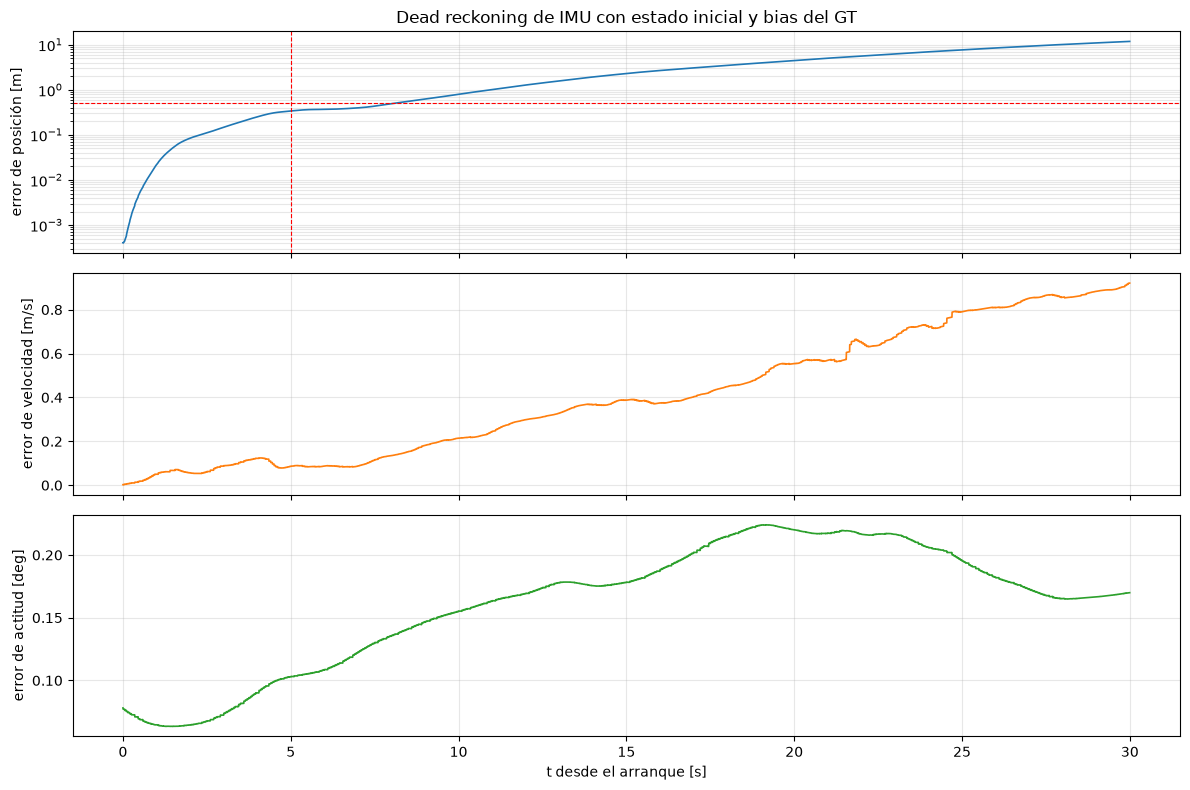

In [39]:
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
axes[0].semilogy(ts - ts[0], np.maximum(err_p, 1e-6), lw=1.2)
axes[0].set_ylabel("error de posición [m]"); axes[0].grid(alpha=0.3, which="both")
axes[0].axhline(0.5, color="r", ls="--", lw=0.8)
axes[0].axvline(5.0, color="r", ls="--", lw=0.8)
axes[0].set_title("Dead reckoning de IMU con estado inicial y bias del GT")

axes[1].plot(ts - ts[0], err_v, lw=1.2, c="C1")
axes[1].set_ylabel("error de velocidad [m/s]"); axes[1].grid(alpha=0.3)

axes[2].plot(ts - ts[0], err_ang, lw=1.2, c="C2")
axes[2].set_ylabel("error de actitud [deg]"); axes[2].set_xlabel("t desde el arranque [s]")
axes[2].grid(alpha=0.3)
plt.tight_layout(); plt.show()

## 3.5 - Los experimentos

### Experimento A - Euler contra midpoint

In [40]:
for metodo in ("euler", "midpoint"):
    p_m, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0, metodo)
    e = np.linalg.norm(p_m - p_gt_ts, axis=1)
    print(f"{metodo:9s}: error a  5 s = {e[np.searchsorted(ts-ts[0], 5)]:7.3f} m   "
          f"a 10 s = {e[np.searchsorted(ts-ts[0], 10)]:7.3f} m   a 30 s = {e[-1]:7.3f} m")

euler    : error a  5 s =   0.400 m   a 10 s =   0.890 m   a 30 s =  12.833 m
midpoint : error a  5 s =   0.339 m   a 10 s =   0.797 m   a 30 s =  11.842 m


Aquí la diferencia entre los dos métodos será mucho menor que en el test
sintético, y eso es información: significa que a 200 Hz **el error de
discretización ya no domina**, lo que domina es el ruido y el bias del sensor.
Es justo lo que justifica que VINS-Mono use midpoint y no se moleste en un RK4:
más orden en el integrador no compraría nada.

Puede incluso salirte **Euler con menos error que midpoint** en algún instante.
No es un bug ni significa que Euler sea mejor: su sesgo de discretización tiene
signo fijo y puede cancelar parcialmente el error de bias, que es mucho mayor.
Cancelación fortuita, no precisión. La prueba de cuál es el bueno es el test
sintético de arriba, donde no hay nada que pueda cancelar nada.

### Experimento B - el peso del bias

corrijo los dos (GT)    : a 5 s =    0.339 m   a 30 s =    11.842 m
no corrijo ninguno      : a 5 s =   17.021 m   a 30 s =  2955.449 m
corrijo solo giro       : a 5 s =    2.271 m   a 30 s =    81.500 m
corrijo solo accel      : a 5 s =   15.527 m   a 30 s =  2914.212 m


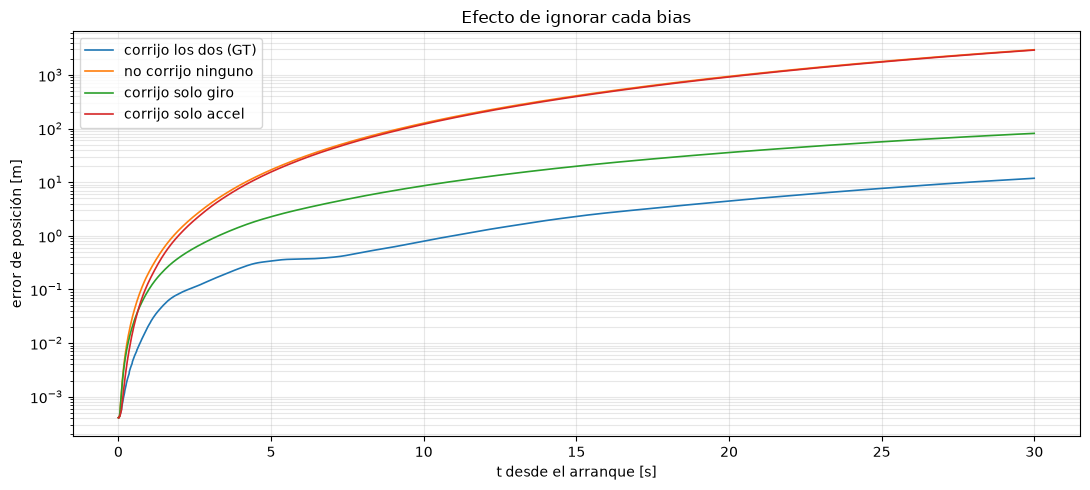

In [41]:
# Ojo a las etiquetas: describen qué bias se CORRIGE, no cuál se ignora.
configuraciones = {
    "corrijo los dos (GT)":     (bg0, ba0),
    "no corrijo ninguno":       (np.zeros(3), np.zeros(3)),
    "corrijo solo giro":        (bg0, np.zeros(3)),
    "corrijo solo accel":       (np.zeros(3), ba0),
}

plt.figure(figsize=(11, 5))
for nombre, (bg, ba) in configuraciones.items():
    p_b, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg, ba)
    e = np.linalg.norm(p_b - p_gt_ts, axis=1)
    plt.semilogy(ts - ts[0], np.maximum(e, 1e-6), lw=1.2, label=nombre)
    print(f"{nombre:24s}: a 5 s = {e[np.searchsorted(ts-ts[0], 5)]:8.3f} m   a 30 s = {e[-1]:9.3f} m")

plt.xlabel("t desde el arranque [s]"); plt.ylabel("error de posición [m]")
plt.title("Efecto de ignorar cada bias")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

In [42]:
# Variante: bias del GT VARIABLE en el tiempo, en vez de congelado en t=T_INICIO.
# El bias es un random walk; en 30 s se mueve, y esto mide cuánto cuesta ignorarlo.
_, _, _, bg_t, ba_t = gt_en(ts)
p_bt, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg_t, ba_t)
e_bt = np.linalg.norm(p_bt - p_gt_ts, axis=1)

print(f"bias constante (t=inicio): a 30 s = {err_p[-1]:8.3f} m")
print(f"bias variable del GT     : a 30 s = {e_bt[-1]:8.3f} m")
print(f"\nderiva del bias de giro en la ventana : "
      f"{np.linalg.norm(bg_t[-1] - bg_t[0])*1e3:.4f} mrad/s")
print(f"deriva del bias de accel en la ventana: "
      f"{np.linalg.norm(ba_t[-1] - ba_t[0])*1e3:.4f} mm/s^2")

bias constante (t=inicio): a 30 s =   11.842 m
bias variable del GT     : a 30 s =   12.416 m

deriva del bias de giro en la ventana : 0.0599 mrad/s
deriva del bias de accel en la ventana: 0.8713 mm/s^2


La asimetría entre los dos bias no es casual, y la fórmula dice exactamente
cuándo domina cada uno:

```
ignorar b_a  ->  error de posición ≈ 0.5 · |b_a| · t²
ignorar b_g  ->  error de actitud ≈ |b_g|·t  ->  aceleración espuria g·|b_g|·t
             ->  error de posición ≈ g · |b_g| · t³ / 6
```

El del giróscopo lleva **un factor `t` de más** y un factor `g ≈ 9.81` de
amplificación. Con `t` pequeño puede perfectamente ganar el del acelerómetro; a
partir del cruce en `t = 3·|b_a| / (g·|b_g|)` gana siempre el del giróscopo, y a
partir de ahí por goleada. Calcula ese cruce con tus números y compáralo con la
gráfica: debería caer donde se cortan las dos curvas.

Por eso todos los VIO estiman el bias de giro con prioridad, y por eso la
inicialización de VINS-Mono empieza precisamente por él.

La segunda celda mide otra cosa: cuánto se pierde por congelar el bias. Si la
diferencia es pequeña, queda justificado modelar el bias como constante dentro de
una ventana corta, que es exactamente la hipótesis de la preintegración de la
Fase 6.

### Experimento C - el peso del estado inicial

In [43]:
rng = np.random.default_rng(42)
print("perturbación de v0 (10 realizaciones por sigma):")
for sigma_v in (0.0, 0.05, 0.2):
    finales = []
    for _ in range(10 if sigma_v > 0 else 1):
        v_pert = v0 + rng.normal(size=3) * sigma_v
        p_c, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v_pert, R0, bg0, ba0)
        e = np.linalg.norm(p_c - p_gt_ts, axis=1)
        finales.append(e[np.searchsorted(ts - ts[0], 10)])
    print(f"  sigma_v0 = {sigma_v:.2f} m/s -> error a 10 s = "
          f"{np.mean(finales):6.3f} +- {np.std(finales):.3f} m   "
          f"(predicción Δp = Δv·t = {sigma_v*10:.2f} m)")

perturbación de v0 (10 realizaciones por sigma):
  sigma_v0 = 0.00 m/s -> error a 10 s =  0.797 +- 0.000 m   (predicción Δp = Δv·t = 0.00 m)
  sigma_v0 = 0.05 m/s -> error a 10 s =  1.081 +- 0.273 m   (predicción Δp = Δv·t = 0.50 m)
  sigma_v0 = 0.20 m/s -> error a 10 s =  2.513 +- 0.783 m   (predicción Δp = Δv·t = 2.00 m)


In [44]:
print("\nperturbación de la actitud inicial:")
for sigma_deg in (0.0, 0.5, 2.0):
    finales = []
    for _ in range(10 if sigma_deg > 0 else 1):
        delta = rng.normal(size=3)
        delta = delta / np.linalg.norm(delta) * np.radians(sigma_deg)
        p_c, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0 @ Exp(delta), bg0, ba0)
        e = np.linalg.norm(p_c - p_gt_ts, axis=1)
        finales.append(e[np.searchsorted(ts - ts[0], 10)])
    print(f"  sigma_R0 = {sigma_deg:.1f}° -> error a 10 s = "
          f"{np.mean(finales):6.3f} +- {np.std(finales):.3f} m   "
          f"(predicción 0.5·g·sinδ·t² = {0.5*9.81*np.sin(np.radians(sigma_deg))*100:.2f} m)")


perturbación de la actitud inicial:
  sigma_R0 = 0.0° -> error a 10 s =  0.797 +- 0.000 m   (predicción 0.5·g·sinδ·t² = 0.00 m)
  sigma_R0 = 0.5° -> error a 10 s =  3.153 +- 1.276 m   (predicción 0.5·g·sinδ·t² = 4.28 m)
  sigma_R0 = 2.0° -> error a 10 s = 13.631 +- 4.468 m   (predicción 0.5·g·sinδ·t² = 17.12 m)


Un error de 0.2 m/s en la velocidad inicial produce ~2 m a los 10 s, y crece
**linealmente**: `Δp = Δv·t`. Un error de 2° en la actitud inicial produce ~17 m,
y crece **cuadráticamente**: la gravedad mal cancelada es una aceleración
constante de `g·sin(δ)`.

Compara las dos tablas con sus predicciones analíticas. La de actitud te saldrá
**por debajo** de la predicción, y es correcto que así sea: la perturbación va en
una dirección aleatoria, y su componente alrededor de la **vertical** es un error
de yaw que no inclina la gravedad y por tanto no contribuye. La predicción es el
caso peor (perturbación puramente horizontal); la media queda en torno a dos
tercios de ella. Si te sale muy por encima, ahí sí hay algo que mirar.

Y esto es por qué la **inicialización visual-inercial** (Fase 8) es un problema en
sí mismo: si no arrancas con velocidad, actitud y gravedad bien estimadas, el
filtro parte de un estado que la propagación amplifica más rápido de lo que las
observaciones lo corrigen.

### Experimento D - la magnitud de la gravedad

`9.81` es un número redondo, no el valor local. En Zúrich la gravedad real es
~9.807 m/s². Un error de 3 mm/s² parece ridículo hasta que lo integras dos veces:
`0.5 · 0.003 · 30² = 1.35 m` a los 30 s.

El matiz es que el bias del acelerómetro del GT ya absorbe parte de esa
diferencia (se estimaron conjuntamente), así que el valor óptimo aquí no es
necesariamente el valor físico local. Barrer el parámetro te dice cuál es la
convención implícita del dataset.

g óptimo (mínimo error a 10 s) = 9.8080 m/s^2
  error con g = 9.8100 : 0.797 m
  error con g = 9.8080 : 0.796 m


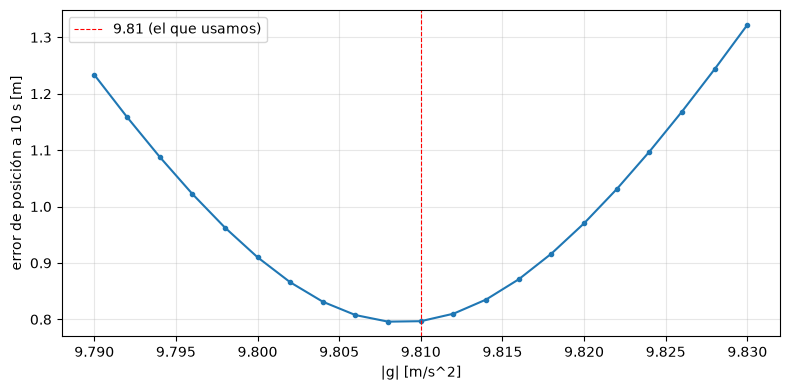

In [45]:
g_valores = np.linspace(9.79, 9.83, 21)
errores_10 = []
for g in g_valores:
    p_g, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0,
                             g_w=np.array([0.0, 0.0, -g]))
    e = np.linalg.norm(p_g - p_gt_ts, axis=1)
    errores_10.append(e[np.searchsorted(ts - ts[0], 10)])
errores_10 = np.array(errores_10)

g_opt = g_valores[np.argmin(errores_10)]
print(f"g óptimo (mínimo error a 10 s) = {g_opt:.4f} m/s^2")
print(f"  error con g = 9.8100 : {errores_10[np.argmin(np.abs(g_valores-9.81))]:.3f} m")
print(f"  error con g = {g_opt:.4f} : {errores_10.min():.3f} m")

plt.figure(figsize=(8, 4))
plt.plot(g_valores, errores_10, marker=".")
plt.axvline(9.81, color="r", ls="--", lw=0.8, label="9.81 (el que usamos)")
plt.xlabel("|g| [m/s^2]"); plt.ylabel("error de posición a 10 s [m]")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Si el mínimo cae muy cerca de 9.81, la convención del dataset y la tuya coinciden
y no hay nada que tocar. Si cae claramente desplazado, tienes una cota de cuánto
error sistemático arrastras — y una razón más para que el filtro de la Fase 5
estime el bias del acelerómetro en lugar de fiarse de una constante.

Un aviso: **no ajustes `g` para que salga bonito**. Estarías metiendo el error del
acelerómetro dentro de la gravedad, y en cuanto cambies de secuencia el ajuste
deja de valer. El experimento es diagnóstico, no calibración.

## 3.6 - La actitud por separado

El error de posición lo mezcla todo: actitud, bias, velocidad inicial. Separar la
actitud es informativo porque **deriva mucho más despacio**, y eso es justo lo que
hace viable la fusión: la cámara corrige posición y escala, mientras la IMU
mantiene una actitud decente entre observaciones.

Además el yaw es un caso aparte. Roll y pitch son **observables** con el
acelerómetro (la gravedad da una referencia absoluta de vertical), pero el yaw no
tiene ninguna referencia inercial: solo lo sostiene la integración del giróscopo,
y por tanto deriva sin cota. En un VIO el yaw es observable solo a través de la
cámara. Separar las componentes lo hace visible.

In [46]:
# Descomposición del error de actitud en "inclinación" (roll+pitch) y yaw.
# La inclinación se mide comparando la vertical del mundo vista desde el body:
# u_b = R^T · (0,0,1). El yaw es lo que queda tras alinear esas dos verticales.
ez = np.array([0.0, 0.0, 1.0])
u_gt = np.einsum("kij,j->ki", np.transpose(R_gt_ts, (0, 2, 1)), ez)
u_dr = np.einsum("kij,j->ki", np.transpose(R_dr, (0, 2, 1)), ez)
err_inclinacion = np.degrees(np.arccos(np.clip(np.einsum("ki,ki->k", u_gt, u_dr), -1, 1)))

R_rel = np.einsum("kij,klj->kil", R_dr, R_gt_ts)          # R_dr · R_gt^T, en el mundo
err_yaw = np.degrees(np.arctan2(R_rel[:, 1, 0], R_rel[:, 0, 0]))

print(f"a 30 s:  total = {err_ang[-1]:.3f}°   inclinación = {err_inclinacion[-1]:.3f}°   "
      f"yaw = {err_yaw[-1]:+.3f}°")

a 30 s:  total = 0.170°   inclinación = 0.168°   yaw = -0.026°


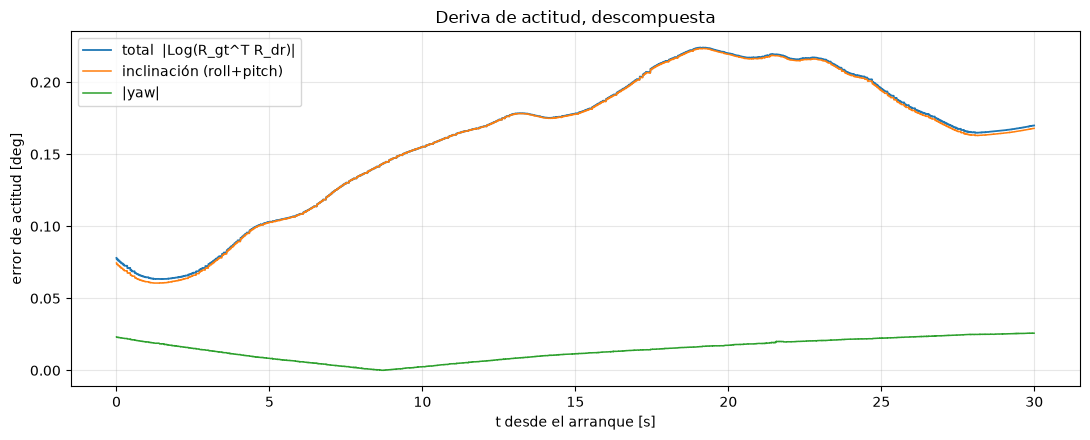

In [47]:
plt.figure(figsize=(11, 4.5))
plt.plot(ts - ts[0], err_ang, lw=1.3, label="total  |Log(R_gt^T R_dr)|")
plt.plot(ts - ts[0], err_inclinacion, lw=1.1, label="inclinación (roll+pitch)")
plt.plot(ts - ts[0], np.abs(err_yaw), lw=1.1, label="|yaw|")
plt.xlabel("t desde el arranque [s]"); plt.ylabel("error de actitud [deg]")
plt.title("Deriva de actitud, descompuesta")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

Con el bias del GT deberías estar por debajo de **1–2°** a los 30 s. Compara ese
número con el error de posición del mismo instante: la actitud se degrada en un
factor pequeño mientras la posición se va a decenas de metros. Toda la asimetría
está en las dos integraciones.

## 3.7 - Visualización 3D

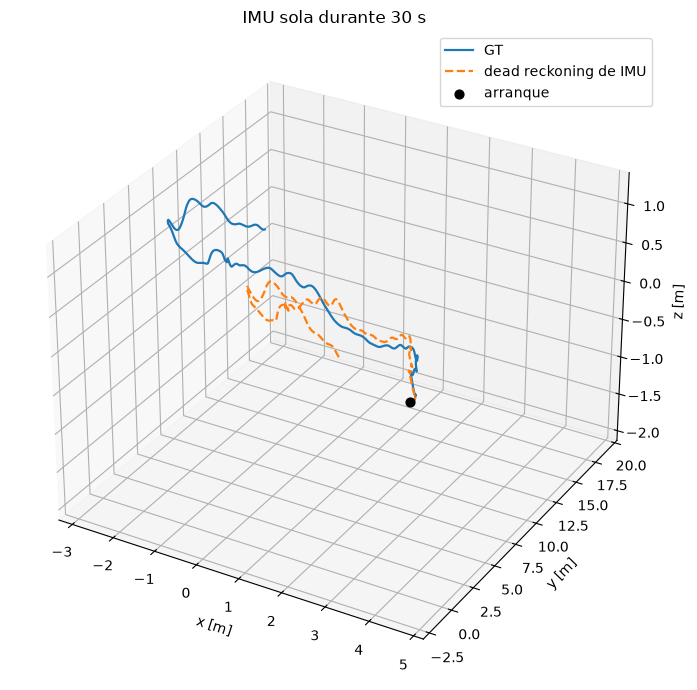

In [48]:
fig = plt.figure(figsize=(8, 7))
ax = fig.add_subplot(projection="3d")
ax.plot(*p_gt_ts.T, lw=1.6, label="GT")
ax.plot(*p_dr.T, lw=1.6, ls="--", label="dead reckoning de IMU")
ax.scatter(*p0, c="k", s=40, label="arranque")
ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]"); ax.set_zlabel("z [m]")
ax.set_title(f"IMU sola durante {ts[-1]-ts[0]:.0f} s")
ax.legend()
plt.tight_layout(); plt.show()

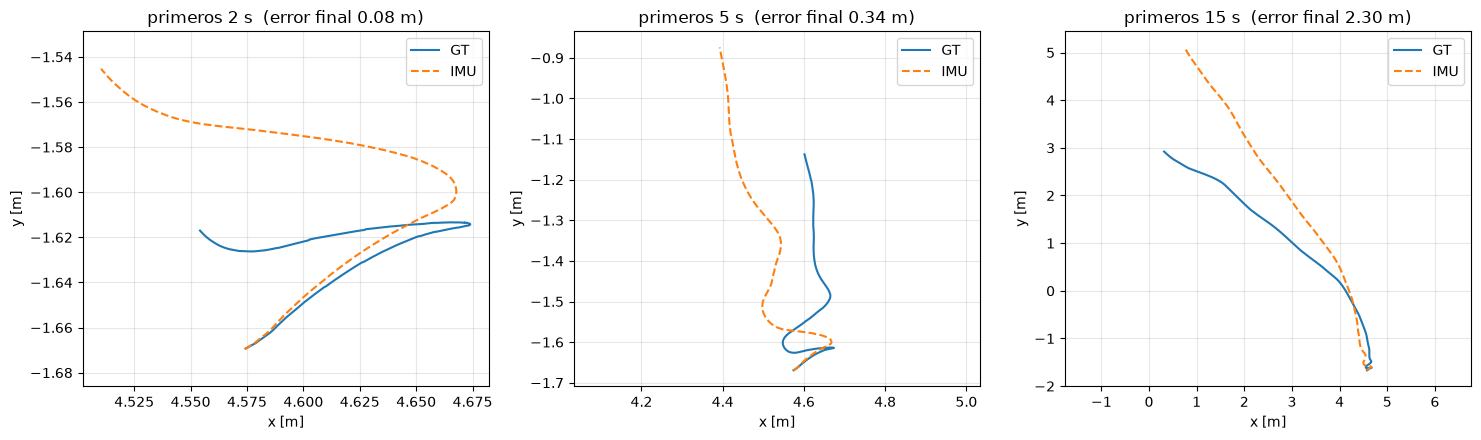

In [49]:
# Las primeras fracciones de la ventana, donde todavía se parecen.
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, T in zip(axes, (2.0, 5.0, 15.0)):
    j = np.searchsorted(ts - ts[0], T)
    ax.plot(p_gt_ts[:j, 0], p_gt_ts[:j, 1], lw=1.5, label="GT")
    ax.plot(p_dr[:j, 0], p_dr[:j, 1], lw=1.5, ls="--", label="IMU")
    ax.set_title(f"primeros {T:.0f} s  (error final {err_p[j-1]:.2f} m)")
    ax.set_xlabel("x [m]"); ax.set_ylabel("y [m]")
    ax.axis("equal"); ax.grid(alpha=0.3); ax.legend()
plt.tight_layout(); plt.show()

La forma es reconocible durante los primeros segundos y luego "se escapa",
típicamente hacia abajo o hacia un lado: es la gravedad mal cancelada por el error
de actitud acumulado, que actúa como una aceleración constante.

## 3.8 - ¿Cuánto dura la IMU sola?

La pregunta importante no es "cuánto deriva en 30 s", sino **cuánto deriva en el
tiempo que separa dos observaciones de la cámara**. Entre dos frames consecutivos
hay 50 ms; entre dos keyframes, del orden de 0.2–1 s.

Este experimento reinicializa desde el GT en muchos instantes distintos y mide el
error acumulado en ventanas cortas. Es la justificación cuantitativa de la
**preintegración** de la Fase 6: si en 50 ms el error es de décimas de milímetro,
la IMU es un sensor de movimiento relativo excelente y el problema es
exclusivamente la acumulación a largo plazo.

In [50]:
inicios = np.linspace(T_INICIO, min(T_INICIO + 60.0, t_gt[-1] - 3.0), 40)

print("ventana     error medio     error p95     equivalente")
for T_ventana, etiqueta in [(0.05, "1 frame de cámara"),
                            (0.20, "keyframe rápido"),
                            (1.00, "keyframe lento"),
                            (3.00, "hueco por oclusión")]:
    errores = []
    for t0 in inicios:
        mm = (t_imu >= t0) & (t_imu <= t0 + T_ventana)
        if mm.sum() < 3:
            continue
        tv = t_imu[mm]
        pv0, Rv0, vv0, bgv, bav = (x[0] for x in gt_en(tv[0]))
        pv, _, _ = integrar_imu(tv, w_medida[mm], a_medida[mm], pv0, vv0, Rv0, bgv, bav)
        p_ref, _, _, _, _ = gt_en(tv)
        errores.append(np.linalg.norm(pv - p_ref, axis=1)[-1])
    errores = np.array(errores)
    print(f"{T_ventana:5.2f} s   {errores.mean()*1e3:9.3f} mm   "
          f"{np.percentile(errores, 95)*1e3:9.3f} mm   {etiqueta}")

ventana     error medio     error p95     equivalente
 0.05 s       0.206 mm       0.748 mm   1 frame de cámara
 0.20 s       1.964 mm       4.723 mm   keyframe rápido
 1.00 s      27.068 mm      54.782 mm   keyframe lento
 3.00 s     133.476 mm     255.787 mm   hueco por oclusión


Compara el error de la ventana de 0.05 s con los ~2.2 cm que se mueve la cámara
entre frames consecutivos (lo mediste en la Fase 2). Si el error de la IMU en ese
intervalo es dos o tres órdenes de magnitud menor que el desplazamiento, la IMU es
una restricción **fortísima** entre frames — y ese es exactamente el papel que
juega en el grafo de factores.

El crecimiento entre las cuatro filas no es lineal: es ahí donde se ve por qué el
tiempo entre keyframes es un parámetro de diseño y no un detalle.

## 3.9 - Inicialización sin GT

Todo lo anterior usa el GT para arrancar, lo cual es tramposo: en un dron real no
existe. La alternativa realista es el **tramo estático** que detectaste en la
Fase 1.

En reposo:

- Todo lo que mide el giróscopo es bias: `b_g = media(w_m)`.
- El acelerómetro apunta hacia arriba: da la vertical del mundo en coordenadas de
  body, y con ella roll y pitch.
- El **yaw queda indeterminado**: girar el dron sobre su eje vertical no cambia
  ninguna medida inercial.
- El bias del acelerómetro **no es separable** de la inclinación (3 ecuaciones,
  5 incógnitas; lo viste en la Fase 1).

In [51]:
def rotacion_entre_vectores(a, b):
    """
    Rotación mínima R tal que R @ a = b, con a y b unitarios (fórmula de Rodrigues).

        R = I + [v]x + [v]x² · 1/(1+c)     con v = a × b,  c = a · b

    El caso c -> -1 (vectores opuestos) es singular: 1/(1+c) explota. Ahí la
    rotación de 180° no es única, así que se elige cualquier eje perpendicular.
    """
    a = np.asarray(a, float) / np.linalg.norm(a)
    b = np.asarray(b, float) / np.linalg.norm(b)
    v = np.cross(a, b)
    c = float(a @ b)
    if c < -1 + 1e-8:
        eje = np.cross(a, [1.0, 0.0, 0.0])
        if np.linalg.norm(eje) < 1e-6:
            eje = np.cross(a, [0.0, 1.0, 0.0])
        return Exp(eje / np.linalg.norm(eje) * np.pi)
    S = sombrero(v)
    return np.eye(3) + S + (S @ S) / (1.0 + c)

In [52]:
def init_estatico(t_ini, t_fin, g=9.81):
    """
    Inicialización inercial a partir de un tramo en reposo.
    Devuelve (R_ws, bg, ba). El yaw de R_ws es ARBITRARIO.
    """
    m = (t_imu >= t_ini) & (t_imu <= t_fin)
    assert m.sum() > 100, "el tramo estático tiene muy pocas muestras"
    w_media = w_medida[m].mean(axis=0)
    a_media = a_medida[m].mean(axis=0)

    bg = w_media                                   # en reposo, el giro solo mide bias

    # "Arriba" en coordenadas de body es la dirección de la fuerza específica.
    z_body = a_media / np.linalg.norm(a_media)
    R_ws = rotacion_entre_vectores(z_body, np.array([0.0, 0.0, 1.0]))

    # Residuo del acelerómetro tras quitar la gravedad predicha.
    ba = a_media - R_ws.T @ np.array([0.0, 0.0, g])
    return R_ws, bg, ba

In [53]:
R_init, bg_init, ba_init = init_estatico(T_ESTATICO[0], T_ESTATICO[1])
t_medio = 0.5 * (T_ESTATICO[0] + T_ESTATICO[1])
p_ref, R_ref, v_ref, bg_ref, ba_ref = (x[0] for x in gt_en(t_medio))

print(f"bias de giro estimado = {bg_init}  rad/s")
print(f"bias de giro del GT   = {bg_ref}  rad/s")
print(f"  diferencia = {np.linalg.norm(bg_init - bg_ref):.3e} rad/s "
      f"({np.degrees(np.linalg.norm(bg_init - bg_ref))*3600:.1f} °/h)")

bias de giro estimado = [-0.00329984  0.02084797  0.0797923 ]  rad/s
bias de giro del GT   = [-0.003175  0.02127   0.078497]  rad/s
  diferencia = 1.368e-03 rad/s (282.2 °/h)


In [54]:
# Error de actitud, separando la parte observable de la que no lo es.
R_err = R_ref.T @ R_init
total = np.degrees(np.linalg.norm(Log(R_err)))
u_ref = R_ref.T @ ez
u_ini = R_init.T @ ez
inclinacion = np.degrees(np.arccos(np.clip(u_ref @ u_ini, -1, 1)))
R_rel_init = R_init @ R_ref.T
yaw = np.degrees(np.arctan2(R_rel_init[1, 0], R_rel_init[0, 0]))

print(f"error de actitud total        = {total:8.3f}°")
print(f"  inclinación (OBSERVABLE)    = {inclinacion:8.3f}°   <- esto sí debe ser pequeño")
print(f"  yaw (NO OBSERVABLE)         = {yaw:+8.3f}°   <- esto es arbitrario, no es un bug")

error de actitud total        =    5.589°
  inclinación (OBSERVABLE)    =    0.862°   <- esto sí debe ser pequeño
  yaw (NO OBSERVABLE)         =   +5.524°   <- esto es arbitrario, no es un bug


In [55]:
# El bias de acelerómetro estimado en reposo es DEGENERADO por construcción.
print(f"ba estimado = {ba_init}   (|ba| = {np.linalg.norm(ba_init):.5f})")
print(f"ba del GT   = {ba_ref}   (|ba| = {np.linalg.norm(ba_ref):.5f})")

# ba_init es paralelo a la gravedad estimada: sus componentes perpendiculares son
# CERO por construcción, no porque el sensor sea perfecto en esos ejes.
g_body = R_init.T @ np.array([0.0, 0.0, 9.81])
componente_paralela = (ba_init @ g_body) / np.linalg.norm(g_body)
perpendicular = ba_init - componente_paralela * g_body / np.linalg.norm(g_body)
print(f"\ncomponente de ba paralela a la gravedad      = {componente_paralela:+.6f} m/s^2")
print(f"componente perpendicular (norma)             = {np.linalg.norm(perpendicular):.2e} m/s^2")
print("  -> exactamente cero: la inclinación se ha 'comido' esos dos grados de libertad")

ba estimado = [-0.03284057  0.00182802  0.00899349]   (|ba| = 0.03410)
ba del GT   = [-0.025144  0.137045  0.075681]   (|ba| = 0.15856)

componente de ba paralela a la gravedad      = -0.034099 m/s^2
componente perpendicular (norma)             = 2.11e-15 m/s^2
  -> exactamente cero: la inclinación se ha 'comido' esos dos grados de libertad


Ese cero exacto es la demostración numérica de lo que viste en la Fase 1: en
reposo hay 3 ecuaciones y 5 incógnitas (2 de inclinación + 3 de bias), así que
cualquier inclinación puede reinterpretarse como bias y al revés. Lo único que
`init_estatico` recupera es el **módulo** del residuo, no su dirección.

Separarlos requiere **excitación**: aceleración no nula en varios ejes, para que
el bias (fijo en body) y la gravedad (fija en el mundo) se comporten de forma
distinta al rotar. Esa es la razón de que la inicialización visual-inercial de
VINS-Mono exija movimiento, y de que falle si arrancas el dron parado.

In [56]:
# Dead reckoning arrancando SOLO con lo del tramo estático (nada de GT salvo el
# origen de coordenadas, que es arbitrario de todos modos).
t_ini_est = T_ESTATICO[1] - 0.2
m = (t_imu >= t_ini_est) & (t_imu <= min(t_ini_est + 30.0, t_gt[-1] - 0.05))
ts_e = t_imu[m]

# Origen: no es observable inercialmente, así que se toma del GT sin remordimiento.
# La velocidad inicial sí es "honesta": en reposo es cero por definición.
p_ini = gt_en(ts_e[0])[0][0]
p_e, v_e, R_e = integrar_imu(ts_e, w_medida[m], a_medida[m],
                             p_ini, np.zeros(3), R_init, bg_init, ba_init)

p_gt_e, R_gt_e, _, _, _ = gt_en(ts_e)
err_e = np.linalg.norm(p_e - p_gt_e, axis=1)
print(f"error a 5 s (sin alinear) = {err_e[np.searchsorted(ts_e-ts_e[0], 5)]:.3f} m")
print(f"error a 30 s (sin alinear) = {err_e[-1]:.3f} m")

error a 5 s (sin alinear) = 0.063 m
error a 30 s (sin alinear) = 10.690 m


error a 5 s (yaw compensado)  = 0.063 m
error a 30 s (yaw compensado) = 10.303 m


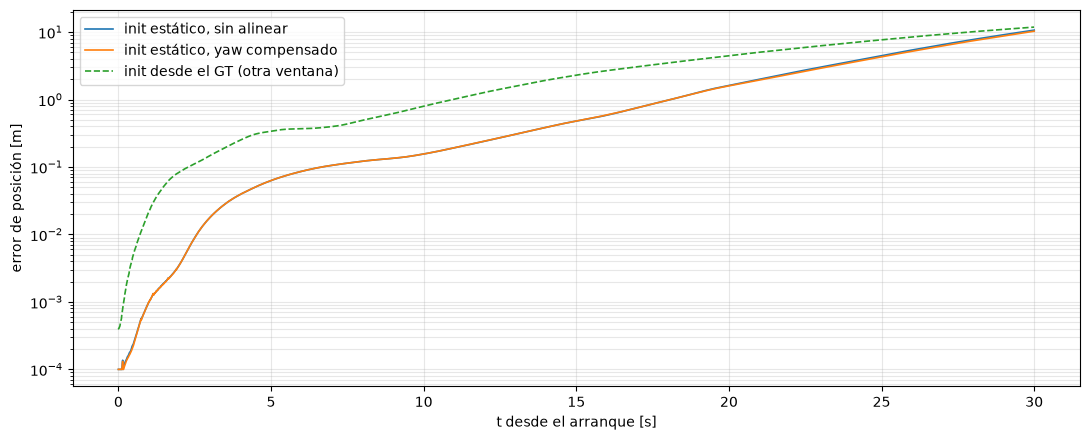

In [57]:
# Casi todo ese error es el yaw arbitrario. Quitándolo (giro rígido en torno a la
# vertical que pasa por el punto de arranque) queda la deriva real.
c, s = np.cos(np.radians(-yaw)), np.sin(np.radians(-yaw))
Rz = np.array([[c, -s, 0.0], [s, c, 0.0], [0.0, 0.0, 1.0]])
p_alin = p_e[0] + (p_e - p_e[0]) @ Rz.T
err_alin = np.linalg.norm(p_alin - p_gt_e, axis=1)

print(f"error a 5 s (yaw compensado)  = {err_alin[np.searchsorted(ts_e-ts_e[0], 5)]:.3f} m")
print(f"error a 30 s (yaw compensado) = {err_alin[-1]:.3f} m")

plt.figure(figsize=(11, 4.5))
plt.semilogy(ts_e - ts_e[0], np.maximum(err_e, 1e-4), lw=1.2, label="init estático, sin alinear")
plt.semilogy(ts_e - ts_e[0], np.maximum(err_alin, 1e-4), lw=1.2, label="init estático, yaw compensado")
plt.semilogy(ts - ts[0], np.maximum(err_p, 1e-4), lw=1.2, ls="--", label="init desde el GT (otra ventana)")
plt.xlabel("t desde el arranque [s]"); plt.ylabel("error de posición [m]")
plt.legend(); plt.grid(alpha=0.3, which="both"); plt.tight_layout(); plt.show()

Fíjate en **dónde** ayuda compensar el yaw: en los primeros segundos el error cae
de forma clara, porque ahí casi todo lo que hay es el desalineamiento del marco.
A los 30 s la mejora desaparece o incluso se invierte, porque para entonces
domina la deriva acumulada y esa no se arregla girando la trayectoria entera.

Esa distinción es la primera aparición de un tema que domina la Fase 7:
**comparar trayectorias que viven en marcos distintos exige alinearlas primero**,
pero la alineación solo quita el error de marco, no el del estimador. Un VIO
monocular tiene 4 grados de libertad no observables (3 de posición y 1 de yaw),
más la escala si no hay IMU. Evaluar sin alinear con Umeyama no mide el error del
estimador: mide el marco de referencia.

## 3.10 - Trampas

| Trampa | Cómo se manifiesta |
|---|---|
| `g_w = (0,0,+9.81)` | La trayectoria sale disparada hacia arriba; el error crece como `g·t²` |
| Sumar `g` antes de rotar `a` | Deriva enorme en cuanto hay rotación: `R·(a+g) ≠ R·a + g` |
| `R ← Exp(δ)·R` en vez de `R·Exp(δ)` | Deriva de actitud en cuanto el dron no está horizontal |
| Usar `dt` fijo de 0.005 s | Sesgo pequeño pero sistemático; usa los `dt` reales |
| Reusar `R[k]` después de actualizarlo | Bug clásico del midpoint: guarda `R_sig` aparte |
| No restar el offset de timestamps | `dt` con ruido de cuantización |
| Aplicar `T_imu_cam` aquí | El GT ya está en el frame del IMU; sobra la extrínseca |
| Cuaternión `wxyz` pasado como `xyzw` | La comprobación de gravedad de 3.2 lo caza al instante |

Las tres primeras son verificables con los argumentos que dejamos en
`integrar_imu`. Un test negativo vale más que un comentario: confirma que el
código *detecta* el error, no solo que hoy no lo tiene.

In [58]:
def error_a(p_prueba, T=5.0):
    return np.linalg.norm(p_prueba - p_gt_ts, axis=1)[np.searchsorted(ts - ts[0], T)]


print(f"correcto                     : {error_a(p_dr):10.3f} m a 5 s")

p_bug, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0,
                           g_w=np.array([0.0, 0.0, +9.81]))
print(f"g_w con signo cambiado       : {error_a(p_bug):10.3f} m a 5 s   "
      f"(predicción 0.5·2g·t² = {0.5*2*9.81*25:.1f} m)")

p_bug, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0, orden="izquierda")
print(f"R <- Exp(δ)·R                : {error_a(p_bug):10.3f} m a 5 s")

p_bug, _, _ = integrar_imu(ts, w_ts, a_ts, p0, v0, R0, bg0, ba0, dt_fijo=0.005)
print(f"dt fijo de 5 ms              : {error_a(p_bug):10.3f} m a 5 s   "
      f"(a 30 s: {np.linalg.norm(p_bug - p_gt_ts, axis=1)[-1]:.3f} m)")

correcto                     :      0.339 m a 5 s
g_w con signo cambiado       :    245.292 m a 5 s   (predicción 0.5·2g·t² = 245.2 m)
R <- Exp(δ)·R                :      8.015 m a 5 s
dt fijo de 5 ms              :      0.339 m a 5 s   (a 30 s: 11.842 m)


El signo de la gravedad da un error de ~245 m a los 5 s: `0.5 · (2g) · t²`, porque
al invertir el signo no solo no cancelas la gravedad sino que la sumas dos veces.
Es tan brutal que es imposible confundirlo con deriva, y por eso es un buen bug:
los que matan son los que producen números casi razonables.

El del `dt` fijo es de la segunda clase, y en EuRoC probablemente te salga casi
idéntico al correcto. No es que la trampa no exista: es que aquí el jitter de los
timestamps es simétrico y de ±30 µs, así que los errores se cancelan en media. La
trampa muerde cuando el sensor **pierde muestras** o el reloj deriva: entonces el
`dt` supuesto y el real difieren siempre en el mismo sentido, el sesgo deja de
cancelarse y se integra dos veces. Con tu IMU de vuelo real, que no vendrá con
timestamps de laboratorio, esto pasa de curiosidad a problema.

## 3.11 - Guardar

In [59]:
q_dr_wxyz = Rotation.from_matrix(R_dr).as_quat()[:, [3, 0, 1, 2]]   # xyzw -> wxyz

SALIDA.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    SALIDA,
    G_W=G_W,
    t_inicio=T_INICIO, t_duracion=T_DURACION,
    ts=ts, p_dr=p_dr, v_dr=v_dr, q_dr_wxyz=q_dr_wxyz,
    p_gt_ts=p_gt_ts, v_gt_ts=v_gt_ts,
    err_p=err_p, err_v=err_v, err_ang=err_ang,
    err_inclinacion=err_inclinacion, err_yaw=err_yaw,
    p0=p0, v0=v0, R0=R0, bg0=bg0, ba0=ba0,
    R_init_estatico=R_init, bg_init_estatico=bg_init, ba_init_estatico=ba_init,
    tramo_estatico=T_ESTATICO, t_arranque=T_ARRANQUE,
    offset_ns=np.int64(OFFSET_NS),
)
print(f"Guardado en {SALIDA} ({SALIDA.stat().st_size / 1e6:.2f} MB)")

Guardado en C:\Users\ander\Documents\00-Proyectos\DRONdevoy\vio-euroc\results\MH_01_easy\fase3_dr.npz (0.93 MB)


In [60]:
print("RESUMEN DE LA FASE 3")
print(f"  ventana                      : [{ts[0]:.2f}, {ts[-1]:.2f}] s ({len(ts)} muestras)")
print(f"  error de posición a  5 s     : {err_p[np.searchsorted(ts-ts[0], 5)]:.3f} m   (criterio < 0.5)")
print(f"  error de posición a 30 s     : {err_p[-1]:.3f} m")
print(f"  error de actitud a 30 s      : {err_ang[-1]:.3f}°")
print(f"  bias de giro (estático vs GT): {np.linalg.norm(bg_init - bg_ref):.2e} rad/s")
print(f"  inclinación inicial sin GT   : {inclinacion:.3f}°")

RESUMEN DE LA FASE 3
  ventana                      : [45.82, 75.81] s (6000 muestras)
  error de posición a  5 s     : 0.339 m   (criterio < 0.5)
  error de posición a 30 s     : 11.842 m
  error de actitud a 30 s      : 0.170°
  bias de giro (estático vs GT): 1.37e-03 rad/s
  inclinación inicial sin GT   : 0.862°
